In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as p
import numpy as np
import flamingo_analysis as fa 
import tangos as db
import flamingo_tangos as ft
import virial_scalings as vs 

from flamingo_analysis import internal_to_keV_cm2


db.init_db('data.db')
db.all_simulations()


/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_analysis.py:547: SyntaxWarning: invalid escape sequence '\,'
  plot_kwargs = {'label': label + "$\,{{\\rm M}}_{{\\odot}}$"} | plot_kwargs


[<Simulation("L0200N0360_HYDRO_FIDUCIAL")>,
 <Simulation("L0200N0360_HYDRO_JETS_STRONGER_AGN")>,
 <Simulation("L0200N0360_HYDRO_JETS")>,
 <Simulation("L0200N0360_HYDRO_WEAK_AGN")>,
 <Simulation("L0200N0360_HYDRO_STRONGEST_AGN")>,
 <Simulation("L0200N0720_HYDRO_FIDUCIAL")>]

In [2]:
from matplotlib.colors import LinearSegmentedColormap

n_col = 4
cmap = LinearSegmentedColormap.from_list("red_blue", ["red", "blue"], N=n_col)
colors = [cmap(i/n_col) for i in range(n_col)]

p.rc('axes', prop_cycle=p.cycler('color', colors))

Plotting mass_enclosed profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5


/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_analysis.py:157: RuntimeWarning: divide by zero encountered in log
  ln_p = np.log(p)


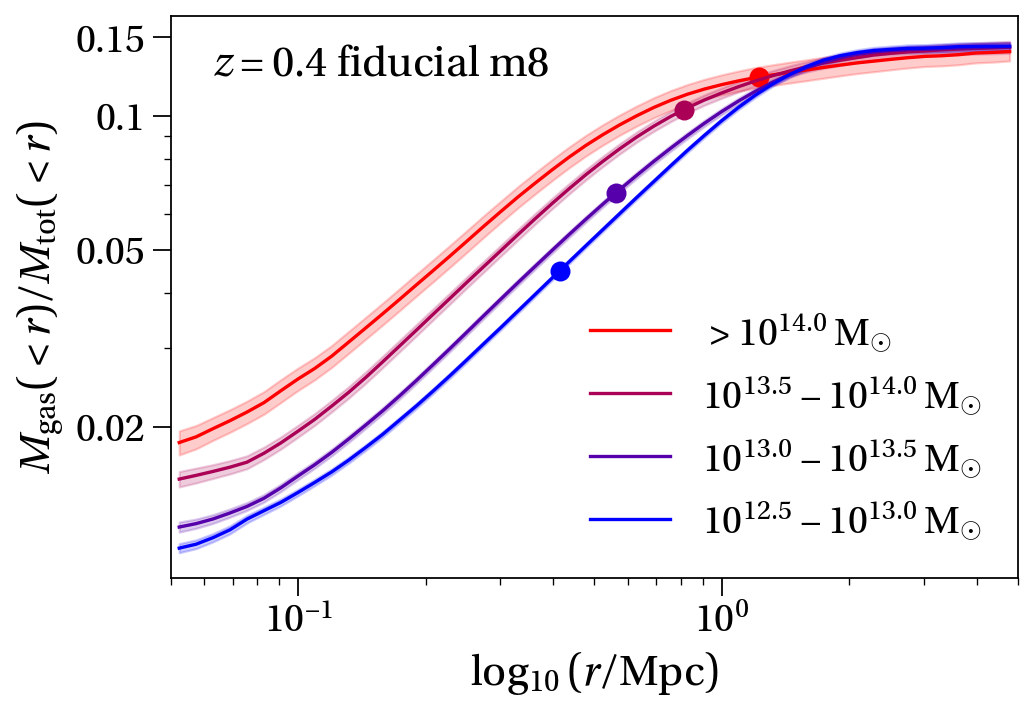

In [3]:
fa.make_profile_plots('mass_enclosed', particle='ratio', tsnum=4, box="L0200N0720_HYDRO_FIDUCIAL", with_legend=True, mark_r200=True, panels=('absolute',))

p.xlabel(r"$\log_{10}(r / {\rm Mpc})$")
p.ylabel(r"$M_{\rm gas}(<r) / M_{\rm tot}(<r)$")
p.yticks([0.02, 0.05, 0.1, 0.15], ['0.02', '0.05', '0.1', '0.15'])
p.xlim(0.05,5.0)
p.text(0.05, 0.95, "$z=0.4$ fiducial m8", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
p.title("")
p.savefig('profiles_absolute_with_r200m.pdf', bbox_inches='tight')


### Cross-check plot

Ensure that the baryon density returns to the cosmic mean at large radii

Plotting density_from_mass() profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5


/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_analysis.py:120: RuntimeWarning: divide by zero encountered in log
  ln_p = np.log(p)


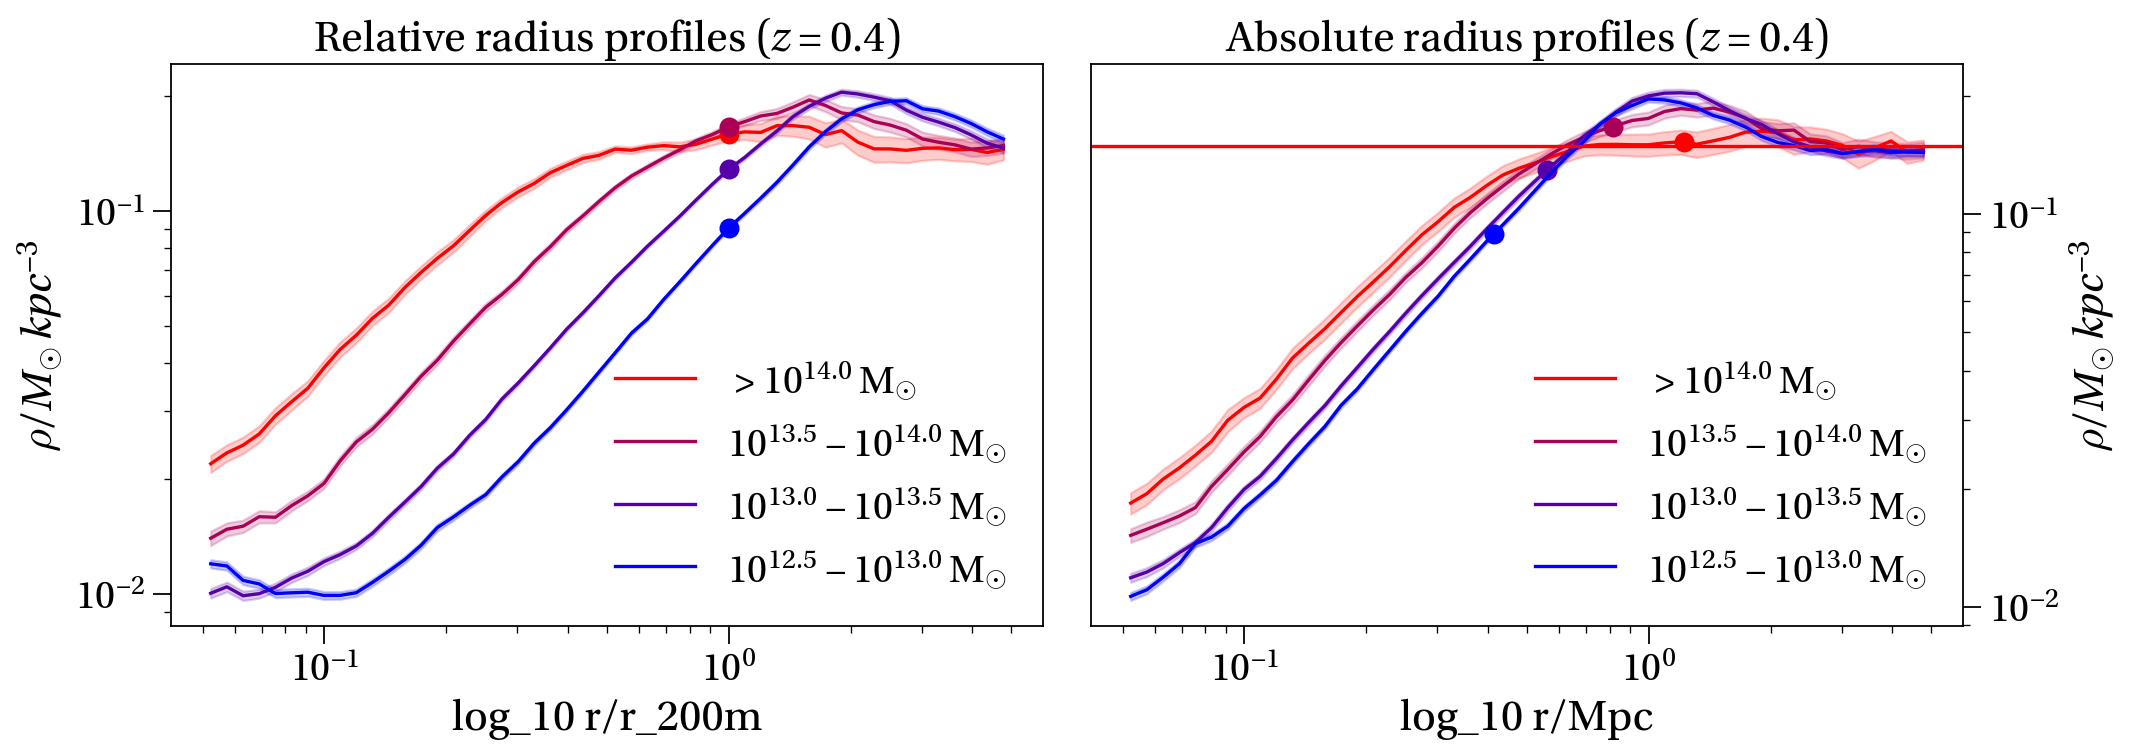

In [5]:
fa.make_profile_plots('density_from_mass()', particle='ratio', tsnum=4, box="L0200N0720_HYDRO_FIDUCIAL", newfig=True, mark_r200=True)
p.axhline(0.14924)

# $\dot{f}_{\rm gas}$ decomposition plot

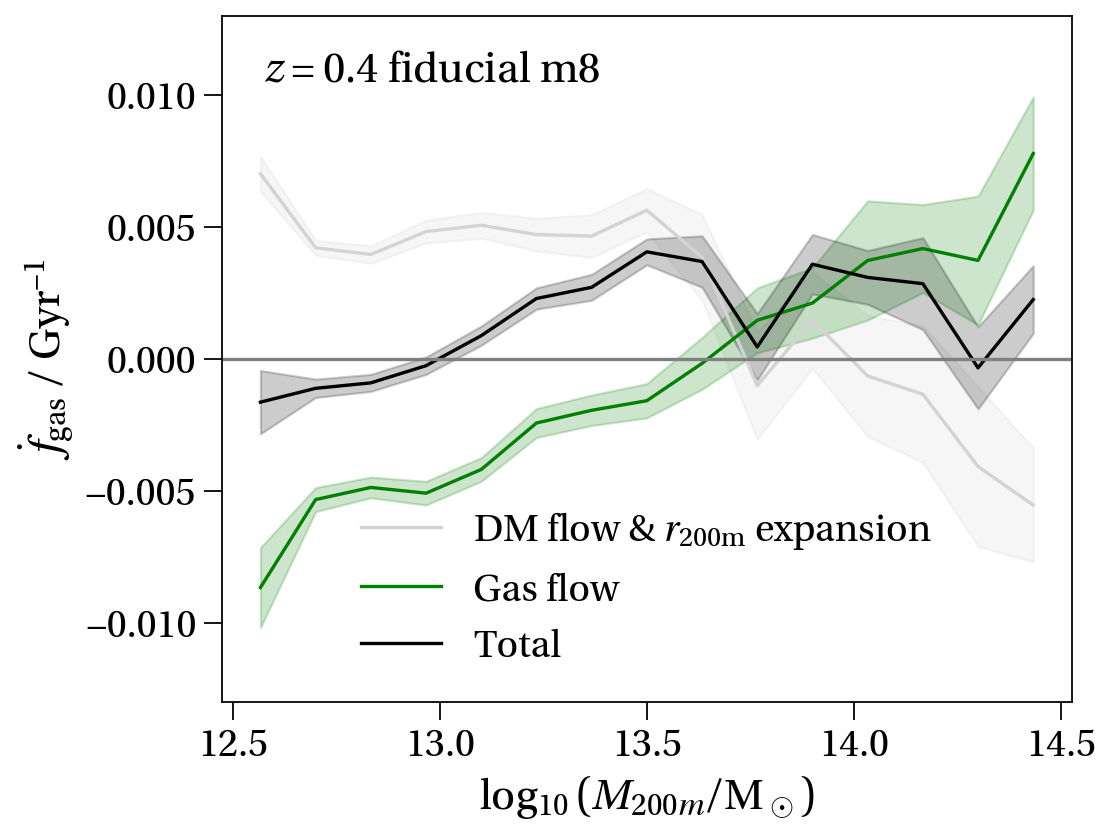

In [13]:
# NB minus sign due to mdot being outflow rather than inflow directed
ts_name = '%720%/%4.hdf5'
gas_term = '-1e9*at(0.0, gas_mdot_r200m_relative)/at(0.0, all_mass_enclosed_r200m_relative)'
dm_term = '1e9*at(0.0, all_mdot_r200m_relative)*at(0.0, gas_mass_enclosed_r200m_relative)/at(0.0, all_mass_enclosed_r200m_relative)**2'
r200_term = '1e9*r200m_dot()*dfgas_dr()'
p.figure()
fa.make_binned_by_mass_plot(f"({dm_term}) + ({r200_term})", plot_kwargs={'color': 'lightgray', 'label': r'DM flow & $r_{\rm 200m}$ expansion'}, ts_name = ts_name, 
                            error_range='uncertainty', use_band=True)
fa.make_binned_by_mass_plot(gas_term, ts_name = ts_name, plot_kwargs={'color': 'green', 'label': 'Gas flow'}, error_range='uncertainty', 
                            use_band=True,)


total = f"({gas_term}) + ({dm_term}) + ({r200_term})"
fa.make_binned_by_mass_plot(total, plot_kwargs={'color': 'black', 'label': 'Total'}, ts_name = ts_name, error_range='uncertainty', use_band=True)
p.title("")
p.ylabel(r"$\dot{f}_{\rm gas}$ / Gyr$^{-1}$")
p.xlabel(r"$\log_{10}(M_{200m} / {\rm M_\odot})$")
p.legend(loc='lower center')
p.text(0.05, 0.95, "$z=0.4$ fiducial m8", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
p.axhline(0.0, color='gray', linestyle='-')
p.ylim(-0.013, 0.013)
p.savefig('fgas_evolution_breakdown.pdf', bbox_inches='tight')


### Cross-check

Should get qualitatively the same from a discrete time-differencing version of the same terms

/Users/app/Science/flamingo/venv/lib/python3.13/site-packages/tangos/live_calculation/builtin_functions/arithmetic.py:85: RuntimeWarning: divide by zero encountered in divide
  result = op(v1,v2)
/Users/app/Science/flamingo/venv/lib/python3.13/site-packages/tangos/live_calculation/builtin_functions/arithmetic.py:85: RuntimeWarning: invalid value encountered in divide
  result = op(v1,v2)


(-0.013, 0.013)

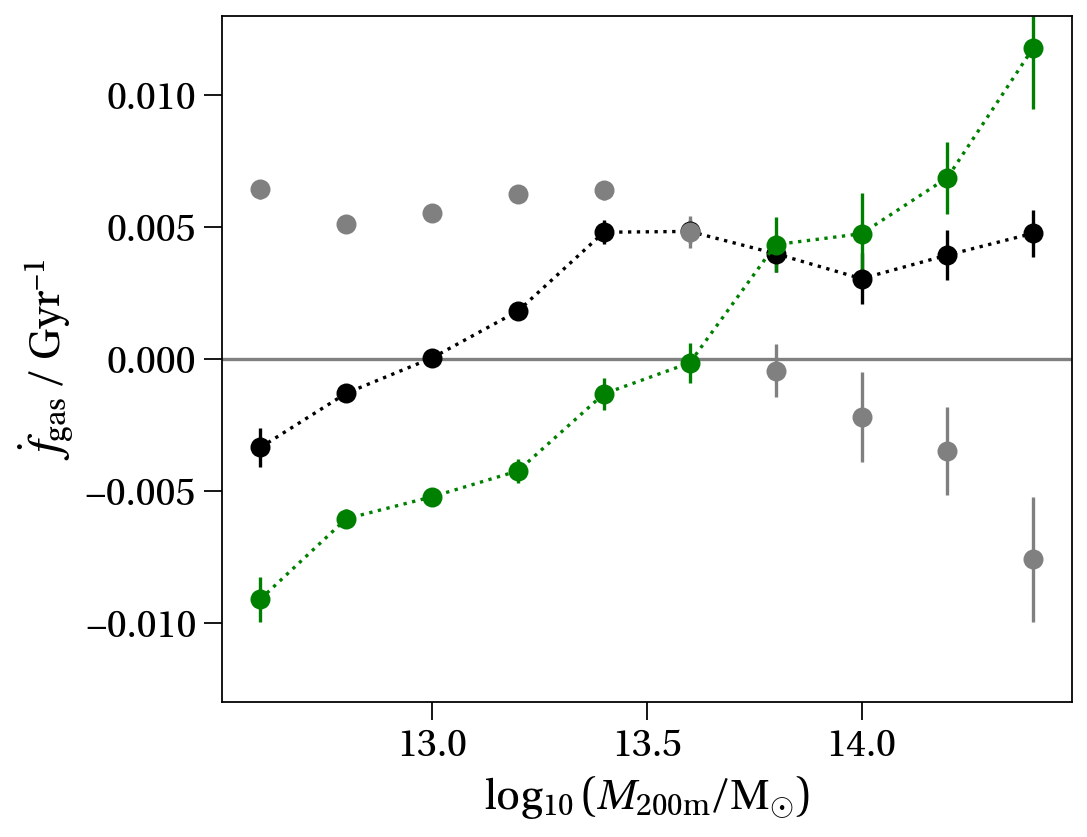

In [8]:
# DISCRETE TIME VERSION of the gas fraction evolution breakdown, as a cross-check

ts_name = '%720%/%4.%'
delta_t_gyr = db.get_timestep(ts_name).time_gyr - db.get_timestep(ts_name).previous.time_gyr

gas_mass_enc = 'at(log10(r200m)-3.0, gas_mass_enclosed)'
delta_gas_mass_enc = f'{gas_mass_enc} - earlier(1).at(later(1).log10(r200m)-3.0, gas_mass_enclosed)'
delta_gas_term = f'({delta_gas_mass_enc}) / at(0.0, dm_mass_enclosed_r200m_relative)'

delta_fgas = f'at(0.0, gas_mass_enclosed_r200m_relative/dm_mass_enclosed_r200m_relative) - earlier(1).at(0.0, gas_mass_enclosed_r200m_relative/dm_mass_enclosed_r200m_relative)'

dm_mass_enc = 'at(log10(r200m)-3.0, dm_mass_enclosed)'
delta_dm_mass_enc = f'earlier(1).at(later(1).log10(r200m)-3.0, dm_mass_enclosed) - {dm_mass_enc}'
delta_dm_term = f'({delta_dm_mass_enc}) * earlier(1).(at(0.0, gas_mass_enclosed_r200m_relative) / at(0.0, dm_mass_enclosed_r200m_relative)) / at(0.0, dm_mass_enclosed_r200m_relative)'

delta_r200_term = 'at(log10(r200m)-3.0, earlier(1).gas_mass_enclosed)/at(log10(r200m)-3.0, earlier(1).dm_mass_enclosed) - at(log10(earlier(1).r200m)-3.0, earlier(1).gas_mass_enclosed)/at(log10(earlier(1).r200m)-3.0, earlier(1).dm_mass_enclosed)'

# all_terms = f'({delta_gas_term}) + ({delta_dm_term} + {delta_r200_term})'  # -- can verify this gives same as delta_fgas, by construction of discrete derivative-like terms

fa.make_binned_by_mass_plot(f'({delta_fgas}) / {delta_t_gyr}', ts_name = ts_name, plot_kwargs={'color': 'black', 'linestyle': ':'}, num_bins = 10, error_range='uncertainty')
fa.make_binned_by_mass_plot(f'({delta_dm_term} + {delta_r200_term}) / {delta_t_gyr}', ts_name = ts_name, plot_kwargs={'color': 'gray'}, num_bins = 10, error_range='uncertainty')
fa.make_binned_by_mass_plot(f'({delta_gas_term}) / {delta_t_gyr}', ts_name = ts_name, plot_kwargs={'color': 'green', 'linestyle': ':'}, num_bins = 10, error_range='uncertainty')

p.title("")
p.ylabel(r'$\dot{f}_{\rm gas}$ / Gyr$^{-1}$')
p.xlabel(r'$\log_{10}(M_{\rm 200m} / {\rm M}_{\odot})$')
p.axhline(0.0, color='gray', linestyle='-')
p.ylim(-0.013, 0.013)

# Main flow rate plot

Plotting mdot_outflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting mdot_inflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting mdot_outflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting mdot_inflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5


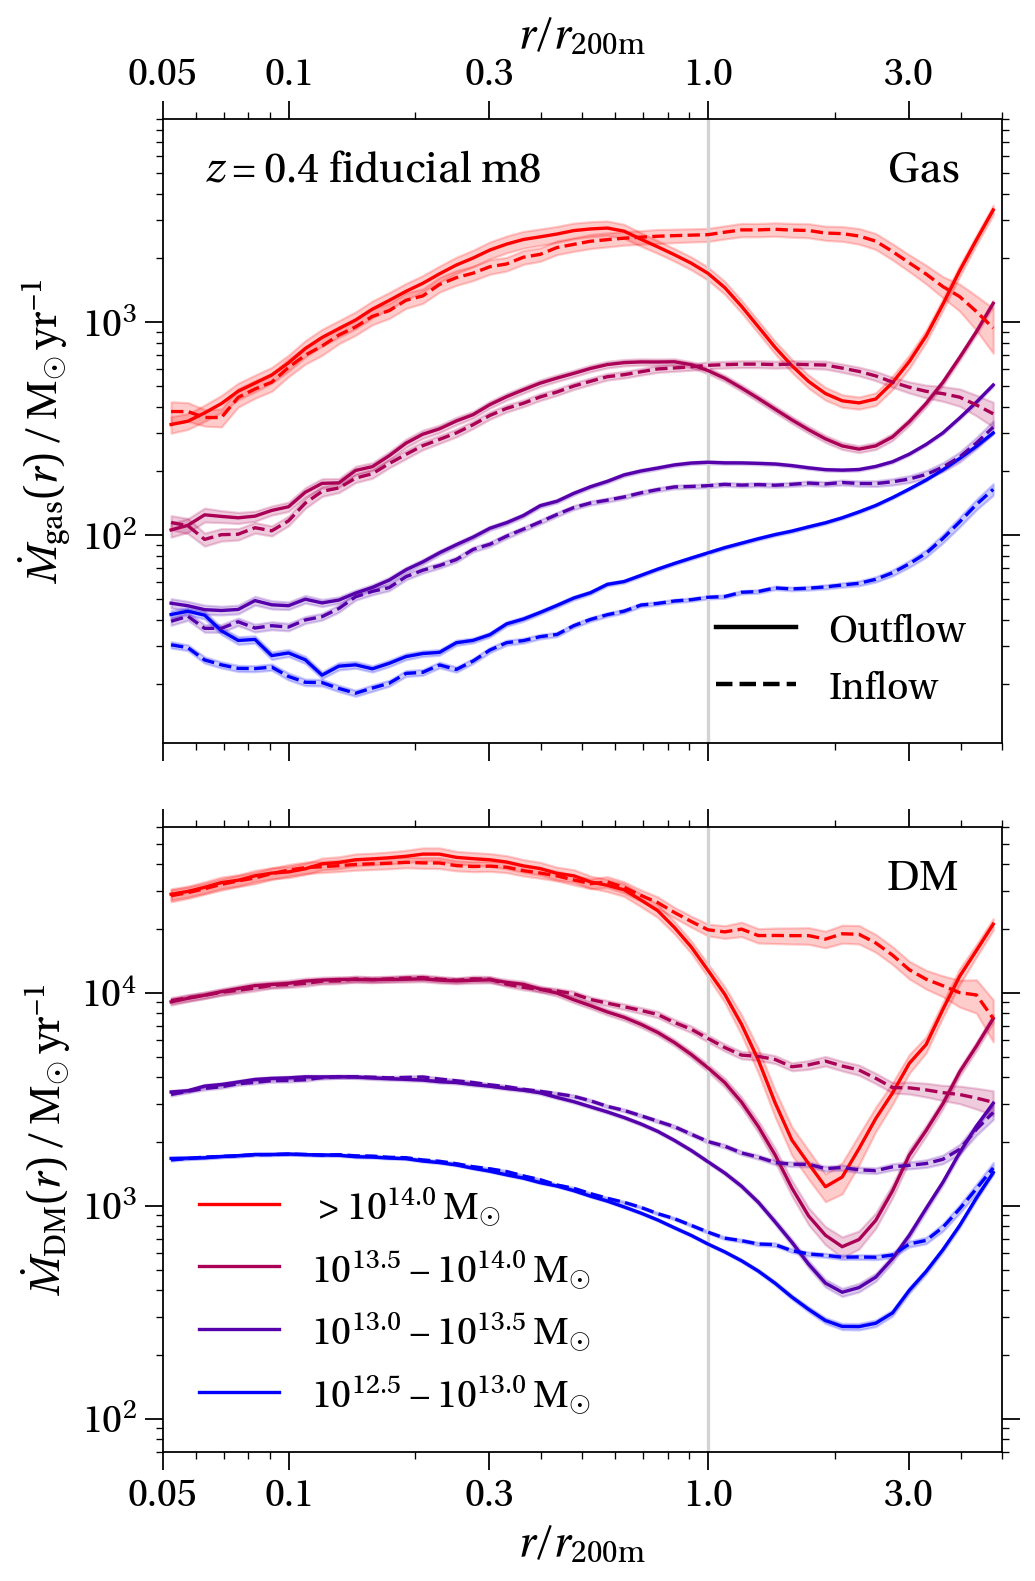

In [9]:
from matplotlib.lines import Line2D

def make_final_flow_plot(particle='gas', tsnum=4):
    p.axvline(1.0, color='lightgray', linestyle='-')

    fa.make_profile_plots('mdot_outflow', particle=particle, tsnum=tsnum, box="L0200N0720_HYDRO_FIDUCIAL", panels=('relative',), newfig=False)

    if particle == 'gas':
        redshift = db.get_timestep(f'%720%/%{tsnum}.hdf5').redshift
        p.text(0.05, 0.95, rf"$z={redshift:.1f}$ fiducial m8", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
        p.text(0.95, 0.95, "Gas", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='right')
        # Create custom legend with black lines
        custom_lines = [Line2D([0], [0], color='black', linewidth=2),
                        Line2D([0], [0], color='black', linewidth=2, linestyle='--')]
        p.legend(custom_lines, ['Outflow', 'Inflow'], loc='lower right')
        p.ylim(0.15*7e1, 0.15*6e4)
    else:
        p.text(0.95, 0.95, "DM", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='right')
        p.legend(loc='best')
        p.ylim(7e1, 6e4)

    fa.make_profile_plots('mdot_inflow', particle=particle, tsnum=4, box="L0200N0720_HYDRO_FIDUCIAL", 
                        plot_kwargs={'linestyle':'--'}, newfig=False, panels=('relative', ))
    

    p.xlabel(r"$r / r_{\rm 200m}$")

    particle_cased = 'gas' if particle=='gas' else 'DM'
    p.ylabel(r"$\dot{M}_{\rm {"+particle_cased+r"}}(r) \, / \, {\rm M}_{\odot}\,{\rm yr}^{-1}$")
    p.title("")
    p.xticks([0.05, 0.1, 0.3, 1.0, 3.0], ['0.05', '0.1', '0.3', '1.0', '3.0'])

    p.gca().yaxis.set_ticks_position('both')
    
    
    p.xlim(0.05,5.0)


p.figure(figsize=(6.9, 5.2*2))
p.subplot(2,1,1)
make_final_flow_plot(particle='gas', tsnum=4)
p.gca().xaxis.set_ticks_position('top')
p.gca().xaxis.set_label_position('top')
p.gca().xaxis.set_ticks_position('both')
p.subplot(2,1,2)
make_final_flow_plot(particle='dm', tsnum=4)
p.gca().xaxis.set_ticks_position('both')

p.tight_layout()
p.savefig("outflow_inflow_profiles.pdf", bbox_inches='tight')


Plotting entropy_inflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting entropy_outflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5


Text(0, 0.5, '$K / \\mathrm{keV\\,cm^2}$')

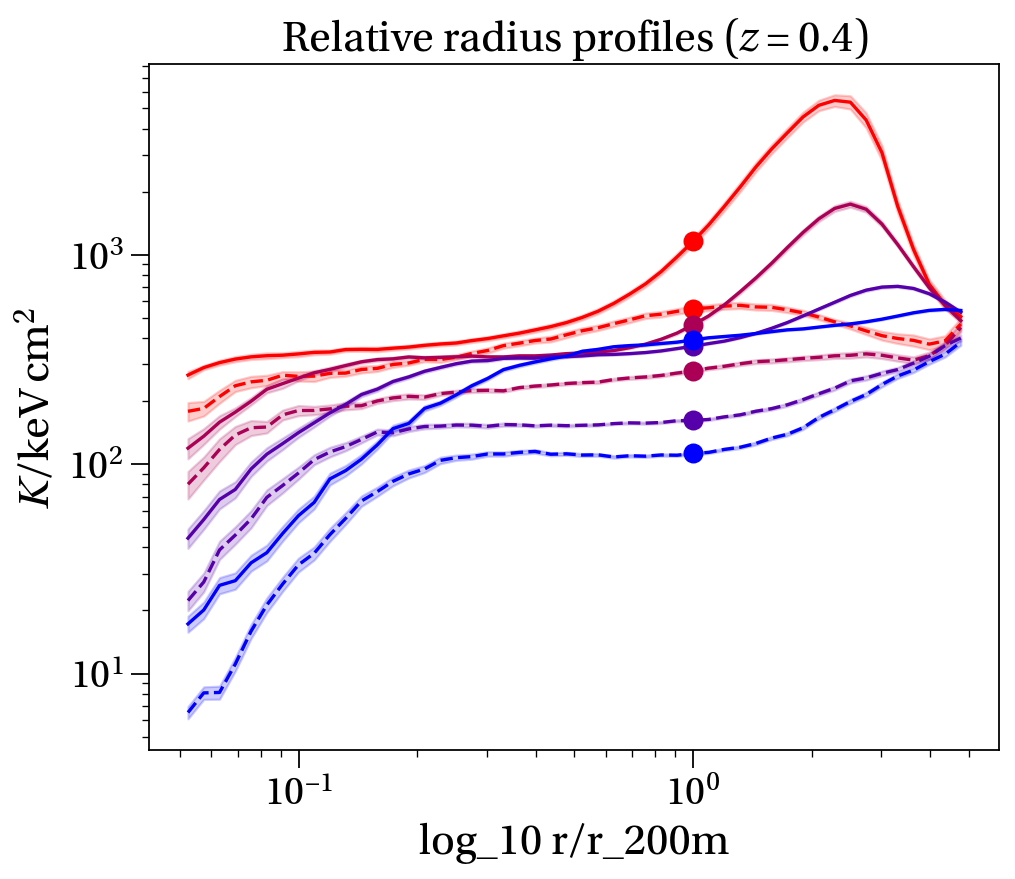

In [53]:
fa.make_profile_plots('entropy_inflow', particle='gas', tsnum=4, box="L0200N0720_HYDRO_FIDUCIAL", 
                        plot_kwargs={'linestyle':'--'}, newfig=False, panels=('relative', ),
                        rescale = internal_to_keV_cm2, mark_r200=True)
fa.make_profile_plots('entropy_outflow', particle='gas', tsnum=4, box="L0200N0720_HYDRO_FIDUCIAL", 
                        plot_kwargs={'linestyle':'-'}, newfig=False, panels=('relative', ),
                        rescale = internal_to_keV_cm2, mark_r200=True)

p.ylabel(r"$K / \mathrm{keV\,cm^2}$")

# Energy rate plot

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vk/zg9_2k_512l3syhc8kdzkzwm0000gp/T/ipykernel_71641/3514741036.py:8: SyntaxWarning: invalid escape sequence '\s'
  label = r'$z=0.4$ jets-4$\sigma$ m9; $r=100\,{\rm kpc}$'


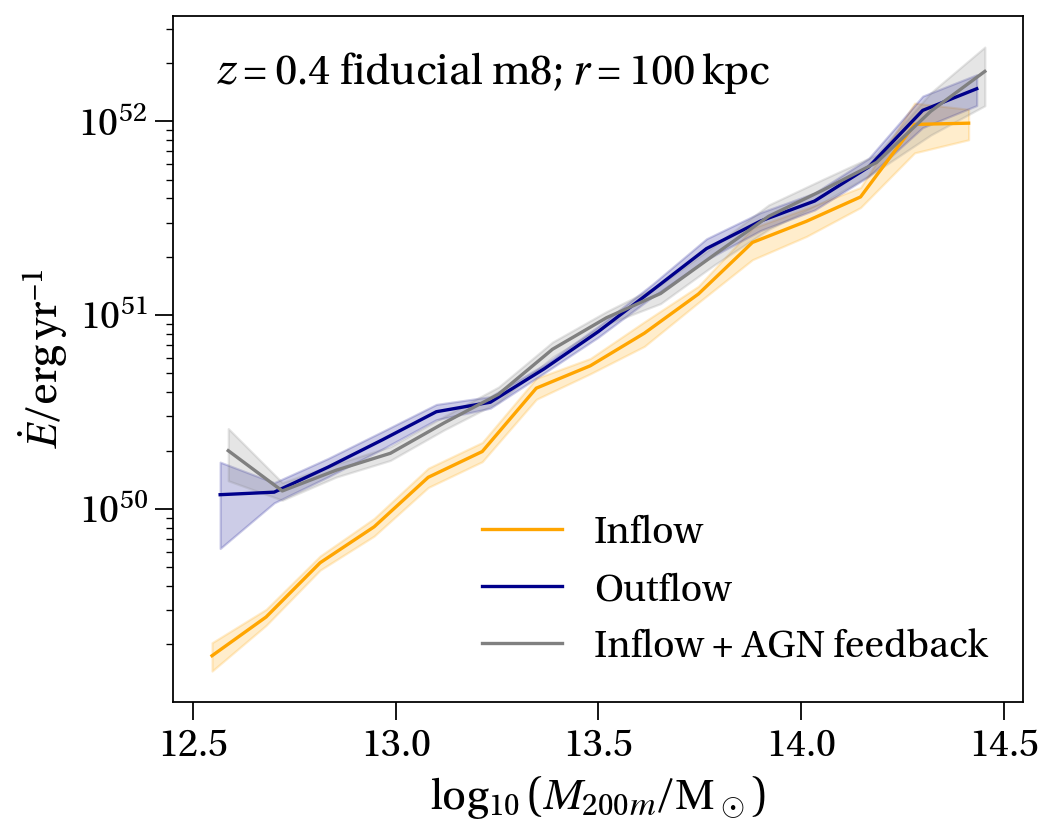

In [26]:
ts_name = '%720%/%4.%'
radius = 0.1
label = r'$z=0.4$ fiducial m8; $r=100\,{\rm kpc}$'

"""
ts_name = '%360%JETS_STRONGER%/%4.%'
radius = 0.10
label = r'$z=0.4$ jets-4$\sigma$ m9; $r=100\,{\rm kpc}$'
"""
fa.make_binned_by_mass_plot(f'1e-6*at(log10({radius}), gas_energy_inflow)',
                            ts_name=ts_name,
                            plot_kwargs={'color': 'orange'},
                            use_band=True, 
                            x_offset=-0.02)
fa.make_binned_by_mass_plot(f'1e-6*at(log10({radius}), gas_energy_outflow)',
                            ts_name=ts_name,
                            use_band=True, 
                            plot_kwargs={'color': 'darkblue'}
                            )
fa.make_binned_by_mass_plot(f'2.7e52*0.0102*InclusiveSphere_30kpc_MostMassiveBlackHoleAccretionRate + 1e-6*at(log10({radius}), gas_energy_inflow)', 
                            ts_name=ts_name, 
                            plot_kwargs={'color': 'grey'},
                            use_band=True, x_offset=0.02)
p.semilogy()
p.title("")
p.xlabel(r"$\log_{10}(M_{200m} / {\rm M_\odot})$")
p.ylabel(r"$\dot{E} / {\rm erg\,yr^{-1}}$")
fa.legend(['Inflow', None, 'Outflow',  None, 'Inflow + AGN feedback'], loc='lower right')
p.text(0.05, 0.95, label, transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')

p.savefig("energy_inflow_outflow_vs_mass.pdf", bbox_inches='tight')

# Entropy summary plot

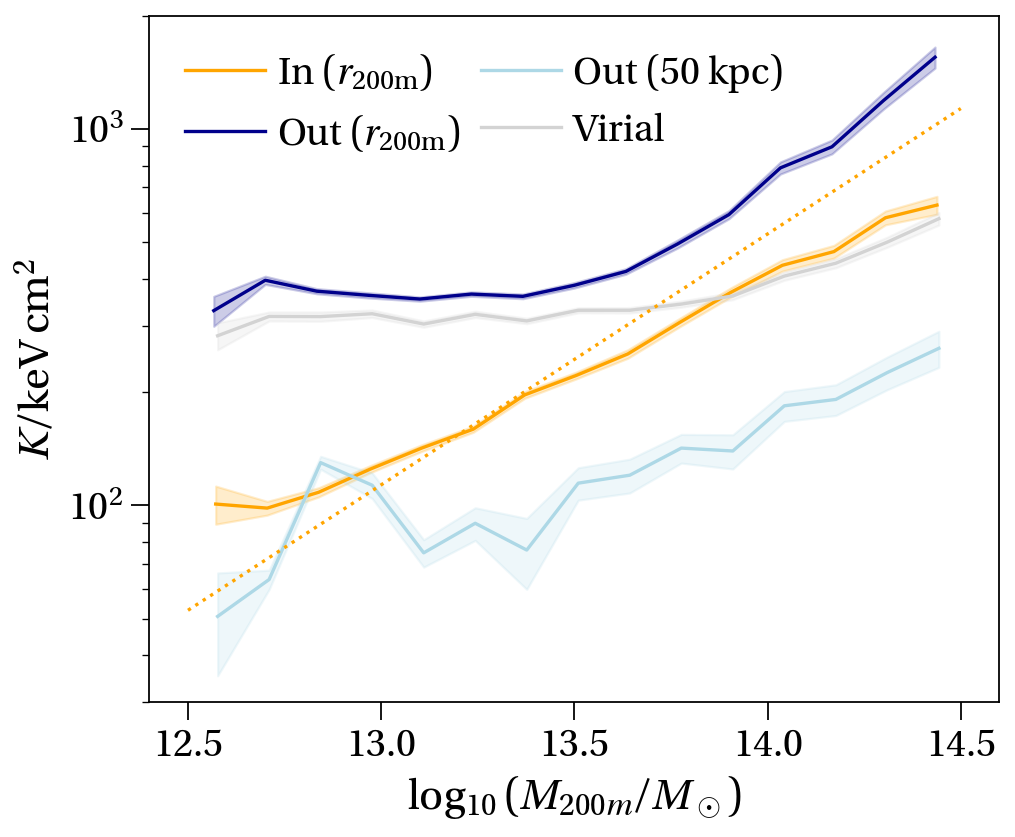

In [38]:
ts = '%720%FID%/%4.%'


fa.make_binned_by_mass_plot(f'{internal_to_keV_cm2} * at(0, gas_entropy_inflow_r200m_relative)', 
                                plot_kwargs={'color': 'orange'},
                                ts_name=ts, use_band=True,
                                weight_property_name=f'at(0, gas_mdot_inflow_r200m_relative)',
                                x_offset=0.005,
                                )
fa.make_binned_by_mass_plot(f'{internal_to_keV_cm2} * at(0, gas_entropy_outflow_r200m_relative)', 
                                plot_kwargs={'color': 'darkblue'},
                                ts_name=ts, use_band=True, 
                                weight_property_name=f'at(0, gas_mdot_outflow_r200m_relative)'
                                )
fa.make_binned_by_mass_plot(f'{internal_to_keV_cm2} * at(-1.3, gas_entropy_outflow)', 
                                plot_kwargs={'color': 'lightblue'},
                                ts_name=ts,
                                weight_property_name=f'at(-1.3, gas_mdot_outflow)',
                                x_offset=0.01, use_band=True,
                                )

fa.make_binned_by_mass_plot(f'{internal_to_keV_cm2} * at(-0.3, gas_entropy_outflow_r200m_relative)', 
                                plot_kwargs={'color': 'lightgrey'},
                                ts_name=ts,
                                weight_property_name=f'at(-0.3, gas_mdot_outflow_r200m_relative)',
                                x_offset=0.01, use_band=True,
                                )

p.xlabel(r"$\log_{10}(M_{200m}/M_\odot)$")
p.ylabel(r"$K / \mathrm{keV\,cm^2}$")
mass_ar = np.linspace(12.5, 14.5, 50)
#entrop_out = vs.outflow_entropy2(10**mass_ar, v_out=250.0, z=0.4)
entrop_in = vs.entropy(10**mass_ar, z=0.4)
#p.plot(mass_ar, entrop_out, color='red', linestyle='--')
p.plot(mass_ar, internal_to_keV_cm2 * entrop_in, color='orange', linestyle=':')

p.title("")
fa.legend([r'In ($r_{\rm 200m}$)', None, r'Out ($r_{\rm 200m}$)', None, 
          'Out (50 kpc)', None, 'Virial'], loc='upper left', ncol=2, columnspacing=0.5, handletextpad=0.3)
p.semilogy()
p.ylim(3e1, 2e3)
p.yticks([100, 1000], ['$10^2$', '$10^3$'])
p.savefig('entropy_inflow_outflow.pdf', bbox_inches='tight')

In [52]:
def get_entropy_floor(ts = '%720%/%8.%', mass_range=(12.5, 12.6)):
    """Get the entropy floor, assumed to be the measured outflow-weighted outflow entropy
    for the low mass halos in the sample"""

    mean, err, xs, _, _ = fa.get_stack(property_name = f'gas_entropy_outflow_r200m_relative', 
                 M_min = mass_range[0], M_max = mass_range[1],
                 timestep_name=ts, 
                 weight_by=f'gas_mdot_outflow_r200m_relative', use_log=False)
    
    virial_index = np.argmin(np.abs(xs))
    return internal_to_keV_cm2 * mean[virial_index], internal_to_keV_cm2 *  err[virial_index]

    

In [57]:
get_entropy_floor('%720%FID%/%4.%')

(np.float64(287.08402236403), np.float64(28.961370838651003))

In [58]:

get_entropy_floor('%360%FID%/%4.%')

(np.float64(268.0266468400269), np.float64(20.49209062594057))

In [59]:
get_entropy_floor('%360%STRONGEST%/%4.%')

(np.float64(631.250507977182), np.float64(82.7421704493329))

In [60]:
get_entropy_floor('%360%WEAK%/%4.%')

(np.float64(180.27192639667578), np.float64(9.046056261984964))

# Letter entropy plot

In [79]:
def make_plot_at_radius(tsnum, property, at=1.0, relative=True, log=False, weight=False, median=False,
                        boxname=r"%360%FIDUCIAL", use_band=False, error_range='std', norm=1.0):
    
    if weight and median:
        raise ValueError("Cannot use both weighting and median in the same plot.")
    log_at = np.log10(at)
    suffix = "_r200m_relative" if relative else ""
    outflow_full_property_name = f'at({log_at}, {property}_outflow{suffix})'
    inflow_full_property_name = f'at({log_at}, {property}_inflow{suffix})'
    if log:
        outflow_full_property_name = f'log10({norm} * abs({outflow_full_property_name}))'
        inflow_full_property_name = f'log10({norm} * abs({inflow_full_property_name}))'
    else:
        outflow_full_property_name = f'{norm} * abs({outflow_full_property_name})'
        inflow_full_property_name = f'{norm} * abs({inflow_full_property_name})'
    fa.make_binned_by_mass_plot(outflow_full_property_name, 
                                plot_kwargs={'color': 'black', 'label': 'Outflow'},
                                ts_name=f"{boxname}/%{tsnum}.hdf5",
                                use_band=use_band, error_range=error_range,
                                weight_property_name=f'at({log_at}, gas_mdot_outflow{suffix})' if weight else 'median' if median else None)
    fa.make_binned_by_mass_plot(inflow_full_property_name, 
                                plot_kwargs={'color': 'orange', 'label': 'Inflow'},
                                ts_name=f"{boxname}/%{tsnum}.hdf5",
                                use_band=use_band, error_range=error_range,
                                weight_property_name=f'at({log_at}, gas_mdot_inflow{suffix})' if weight else 'median' if median else None,
                                x_offset = 0.02)
    p.xlabel(r"$\log_{10}(M_{200m}/M_\odot)$")
    location_label = f"at {at:.1f} $r_{{200m}}$" if relative else f"{at:.1f} Mpc"
    p.ylabel(rf"{property.replace('_', ' ').title()} at {location_label}")
    p.title("")

def make_virial_entropy_plot(tsnum, at=1.0, relative=True, boxname=r"%360%FIDUCIAL", 
                             use_band=False, error_range='std', weight=False, median=False):
    log_at = np.log10(at)
    internal_to_keV_cm2 = 0.570304
    make_plot_at_radius(tsnum, f'gas_entropy', at=at, relative=relative, 
                        boxname=boxname, use_band=use_band, error_range=error_range, weight=weight, median=median, norm=internal_to_keV_cm2)
    p.title("")

    z = db.get_timestep(f"{boxname}/%{tsnum}.hdf5").redshift
    K1 = (vs.entropy(10**12.5, z=z))
    K2 = (vs.entropy(10**14.5, z=z))

    p.plot([12.5, 14.5], [K1*internal_to_keV_cm2, K2*internal_to_keV_cm2], color='brown', linestyle='--', label='Virial')
    p.title(f"z={z:.1f}")
    p.legend()
    p.semilogy()
    p.xticks([12.5, 13.0, 13.5, 14.0, 14.5], ['', '13.0', '', '14.0', ''])
    ax = p.gca()
    ax.xaxis.set_tick_params(which='major', length=8)
    for label, tick in zip(ax.get_xticklabels(), ax.xaxis.get_major_ticks()):
        if label.get_text() == '':
            tick.tick1line.set_markersize(4)
            tick.tick2line.set_markersize(4)

In [77]:
snapnum = 4

redshift = db.get_timestep(f'%720%/%{snapnum}.hdf5').redshift

v_entrop_kwargs = {'relative': True, 
                   'error_range': (16, 84), 
                   'weight': True,
                   'median': False,
                   'use_band': True}
ylim = (20., 3e3)
ylabel = r"$K/{\rm keV\,cm^2}$"



def make_panels_at_radius(vnum, vthis, at):
      def _add_panel_annotation(model_description):
            radius = f"{at:.1f} $r_{{200m}}$" if at != 1.0 else "$r_{200m}$"
            if vthis == 0:
                  text_to_render = model_description
                  if vnum > 1 :
                        text_to_render += "\n" + radius
            else:
                  text_to_render = radius

            p.text(0.05, 0.95, text_to_render, transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
            

      p.subplot(vnum, 4, vthis*4+1)

      make_virial_entropy_plot(snapnum, at=at, **v_entrop_kwargs)
      p.ylim(ylim)
      p.ylabel(ylabel)
      p.title("")
      if vthis>0:
            fa.remove_existing_legend()
      _add_panel_annotation("Fiducial")

      p.subplot(vnum, 4, vthis*4+2)
      make_virial_entropy_plot(snapnum, at=at, **v_entrop_kwargs, boxname='%WEAK%')
      p.ylim(ylim)
      p.ylabel("")
      p.title("")
      fa.remove_existing_legend()
      p.gca().set_yticks([])
      _add_panel_annotation(r"$f_{\rm gas} + 2 \sigma$")

      p.subplot(vnum, 4, vthis*4+3)
      make_virial_entropy_plot(snapnum, at=at, **v_entrop_kwargs, boxname='%STRONGEST%')
      p.ylim(ylim)
      p.ylabel("")
      p.title("")
      fa.remove_existing_legend()
      p.gca().set_yticks([])
      _add_panel_annotation(r"$f_{\rm gas} - 8 \sigma$")

      p.subplot(vnum, 4, vthis*4+4)
      make_virial_entropy_plot(snapnum, at=at, **v_entrop_kwargs, boxname='%JETS_STR%')
      p.ylim(ylim)
      p.ylabel(ylabel)
      p.title("")
      p.gca().yaxis.set_label_position('right')
      p.gca().yaxis.set_ticks_position('right')
      fa.remove_existing_legend()
      _add_panel_annotation(r"Jets $f_{\rm gas} - 4 \sigma$")

      p.subplots_adjust(hspace=0, wspace=0)
      

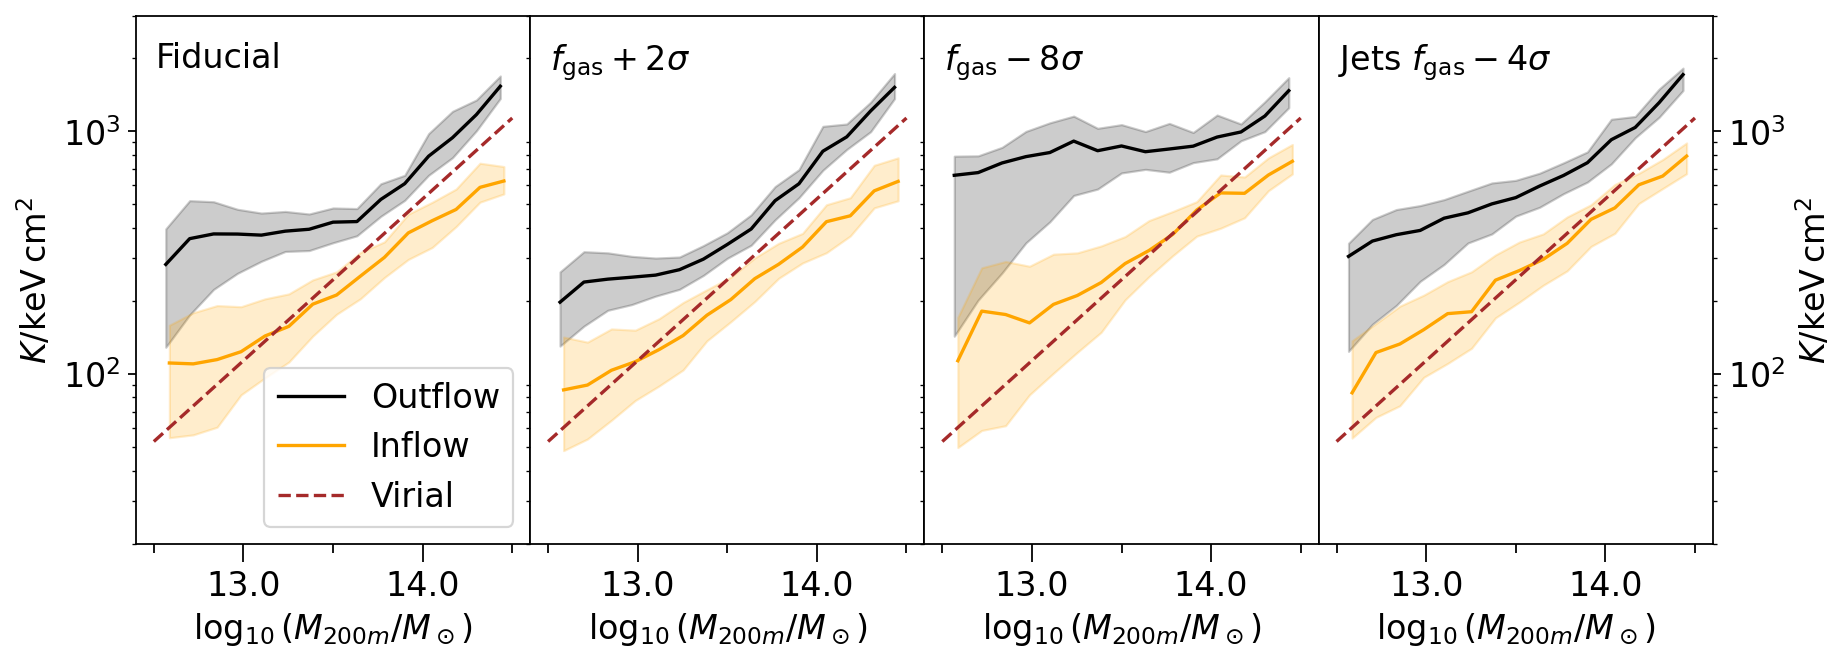

In [18]:
p.figure(figsize=(12.8,4.0))
# for letter - use default matplotlib styles with larger font
with p.rc_context(p.rcParamsDefault | {"font.size": 15}):
      make_panels_at_radius(1, 0, at=1.0)
      p.savefig('entropy_letter_fig.pdf', bbox_inches='tight')
      p.show()

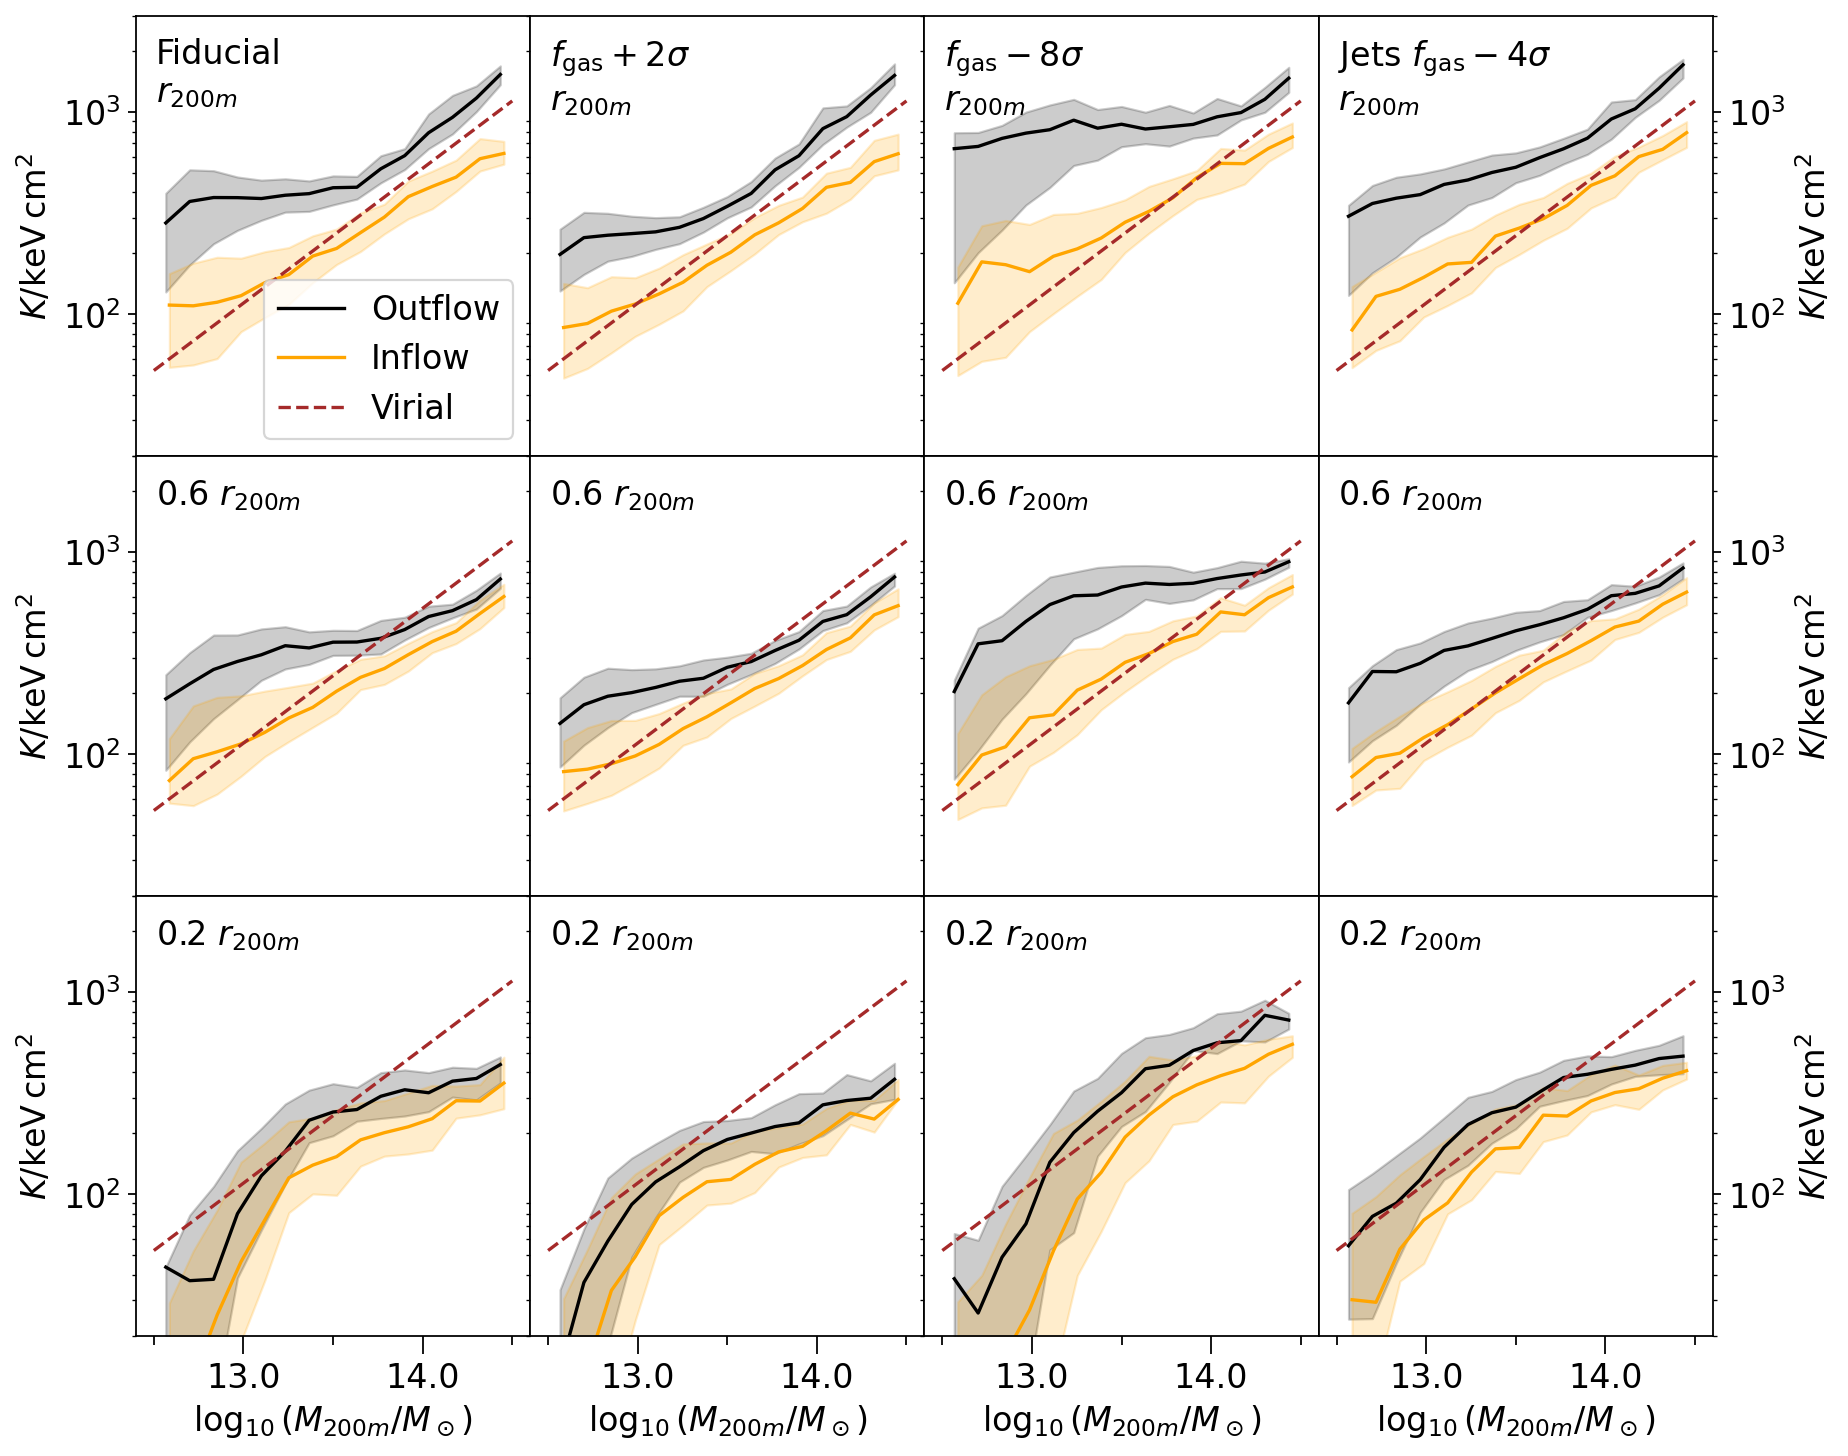

In [80]:
p.figure(figsize=(12.8,10.0))
# for letter - use default matplotlib styles with larger font
with p.rc_context(p.rcParamsDefault | {"font.size": 15}):
      make_panels_at_radius(3, 0, at=1.0)
      make_panels_at_radius(3, 1, at=0.6)
      make_panels_at_radius(3, 2, at=0.2)

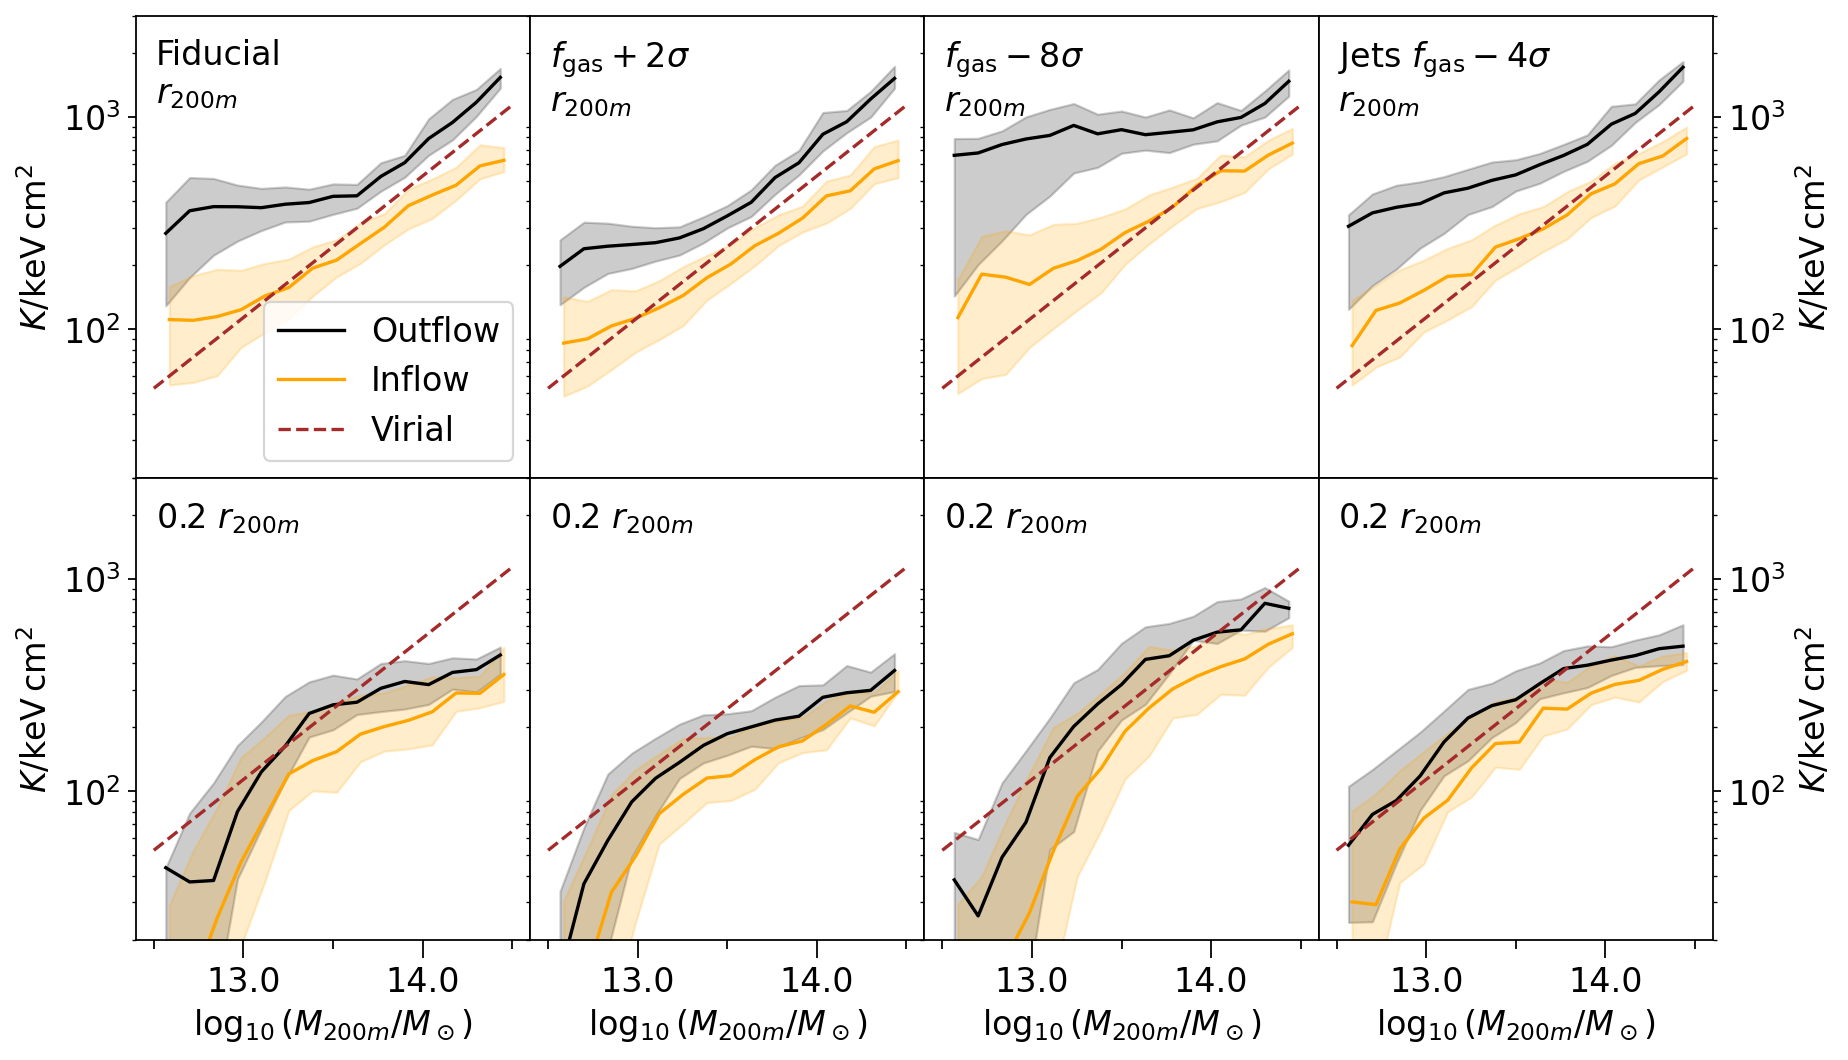

In [7]:
p.figure(figsize=(12.8,7.0))
# for letter - use default matplotlib styles with larger font
with p.rc_context(p.rcParamsDefault | {"font.size": 15}):
      make_panels_at_radius(2, 0, at=1.0)
      make_panels_at_radius(2, 1, at=0.2)
      p.savefig('entropy_letter_fig_tworow.pdf', bbox_inches='tight')
      p.show()

# Flow anisotropy plot

In [51]:
def four_panel_flow_plot(ts_top = "L0200N0360_HYDRO_FIDUCIAL/%4.hdf5", label_top='Fiducial',
                         ts_bottom = "L0200N0360_HYDRO_JETS_STRONGER_AGN/%4.hdf5", label_bottom='Jets-4$\sigma$',
                         M_min=13.0, M_max=13.2):
    fig = p.figure(figsize=(12,9))

    p.subplot(221)
    fa.make_stacked_entropy_image_plot(ts_top,  M_min=M_min, M_max=M_max, axis='13', panel_label=label_top)
    p.gca().xaxis.tick_top()
    p.gca().xaxis.set_label_position('top')




    p.subplot(222)
    fa.make_stacked_entropy_image_plot(ts_top,  M_min=M_min, M_max=M_max, 
                                    axis='12', panel_label=label_top)
    p.gca().xaxis.tick_top()
    p.gca().xaxis.set_label_position('top')
    p.gca().yaxis.tick_right()
    p.gca().yaxis.set_label_position('right')


    p.subplot(223)
    fa.make_stacked_entropy_image_plot(ts_bottom, M_min=M_min, M_max=M_max, axis='13', panel_label=label_bottom)

    p.subplot(224)
    fa.make_stacked_entropy_image_plot(ts_bottom,  M_min=M_min, M_max=M_max, axis='12', panel_label=label_bottom)
    p.gca().yaxis.tick_right()
    p.gca().yaxis.set_label_position('right')

    from pynbody.plot import util
    import matplotlib
    Q = list(filter(lambda x: isinstance(x, matplotlib.quiver.Quiver), p.gca().get_children()))[-1]
    qk = util.PynbodyQuiverKey(Q, 1.35, 0.1, # <-- fragile - trial and error positioning outside axes!
                                500, "500 km/s",
                                color='k', labelcolor='k',
                                boxedgecolor='w', boxfacecolor='w')

    im = fig.axes[-1].images[-1]
    fig.subplots_adjust(left=0.0, right=9./12., bottom=0.0, top=1.0, wspace=0.0, hspace=0.0)
    cax = fig.add_axes([10.3/12., 0.25, 0.02, 0.5])
    fig.colorbar(im, cax=cax).set_label(r"$\log_{10} \left( K / {\rm keV\,cm^{2}} \right)$")


    fig.add_artist(qk)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vk/zg9_2k_512l3syhc8kdzkzwm0000gp/T/ipykernel_81435/3607095091.py:2: SyntaxWarning: invalid escape sequence '\s'
  ts_bottom = "L0200N0360_HYDRO_JETS_STRONGER_AGN/%4.hdf5", label_bottom='Jets-4$\sigma$',


/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_analysis.py:125: RuntimeWarning: invalid value encountered in log
  ln_p = np.log(p)
/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_analysis.py:125: RuntimeWarning: invalid value encountered in log
  ln_p = np.log(p)
/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_analysis.py:125: RuntimeWarning: invalid value encountered in log
  ln_p = np.log(p)
/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_analysis.py:125: RuntimeWarning: invalid value encountered in log
  ln_p = np.log(p)


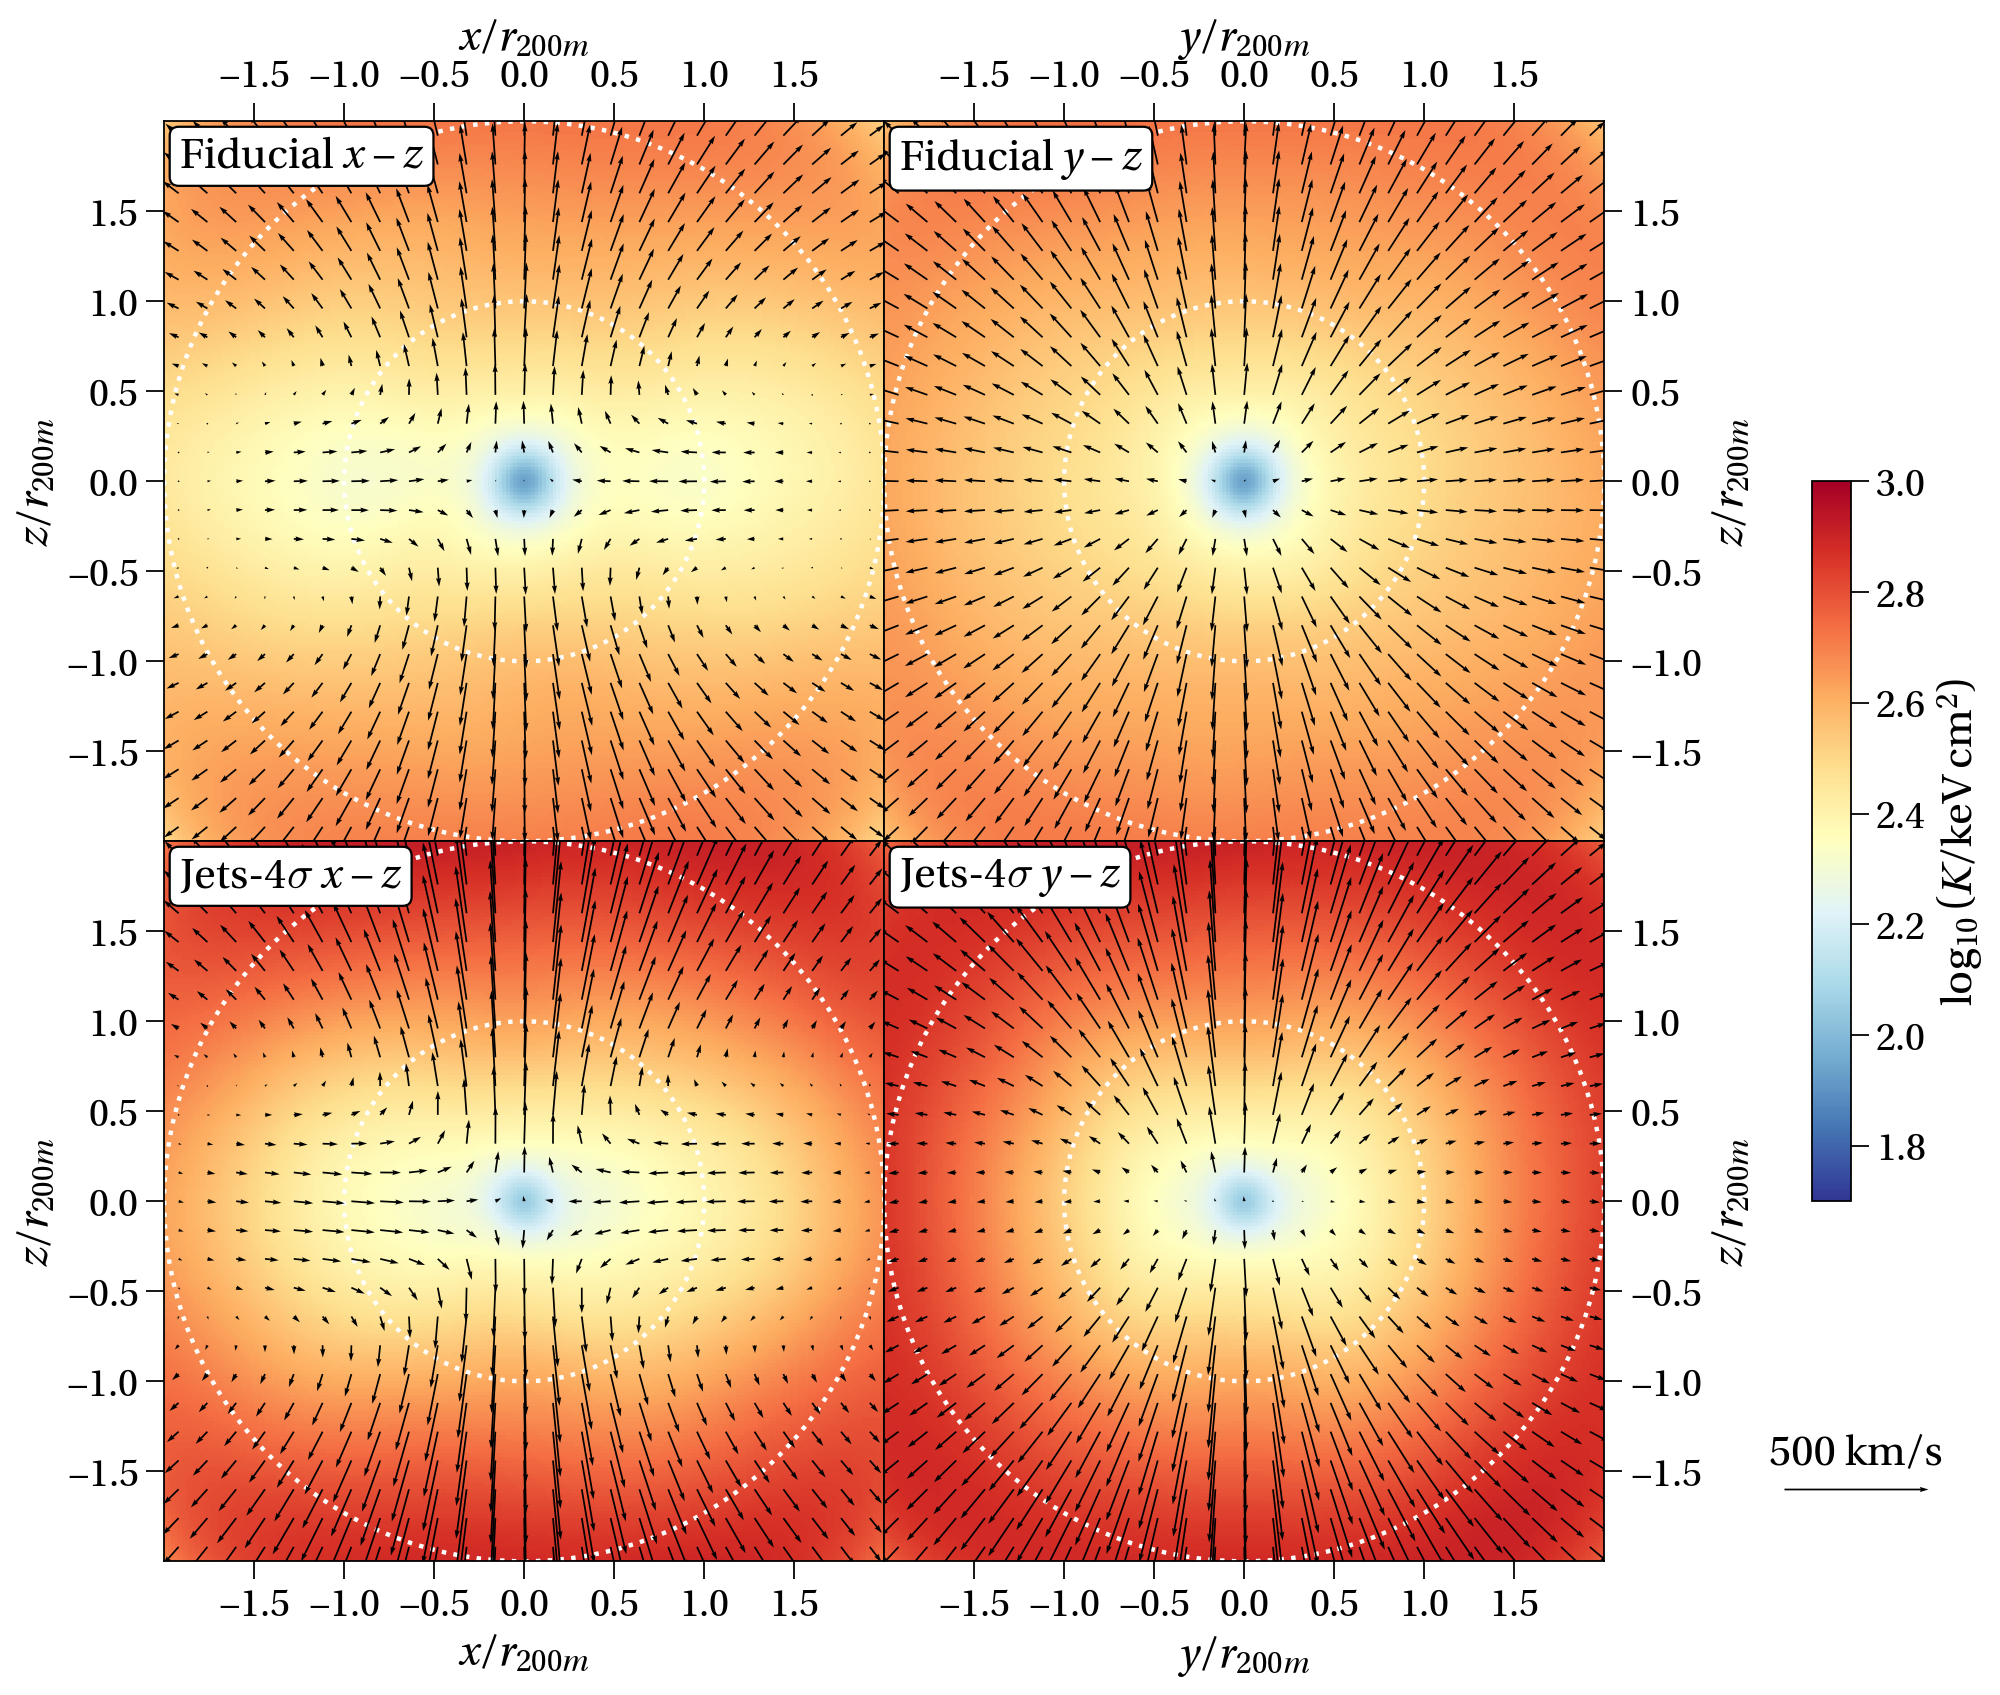

In [52]:
four_panel_flow_plot()

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vk/zg9_2k_512l3syhc8kdzkzwm0000gp/T/ipykernel_4535/2302185086.py:6: SyntaxWarning: invalid escape sequence '\s'
  fa.legend(['Fiducial', 'mean', None, 'Jets-4$\sigma$', 'mean'], loc='best')


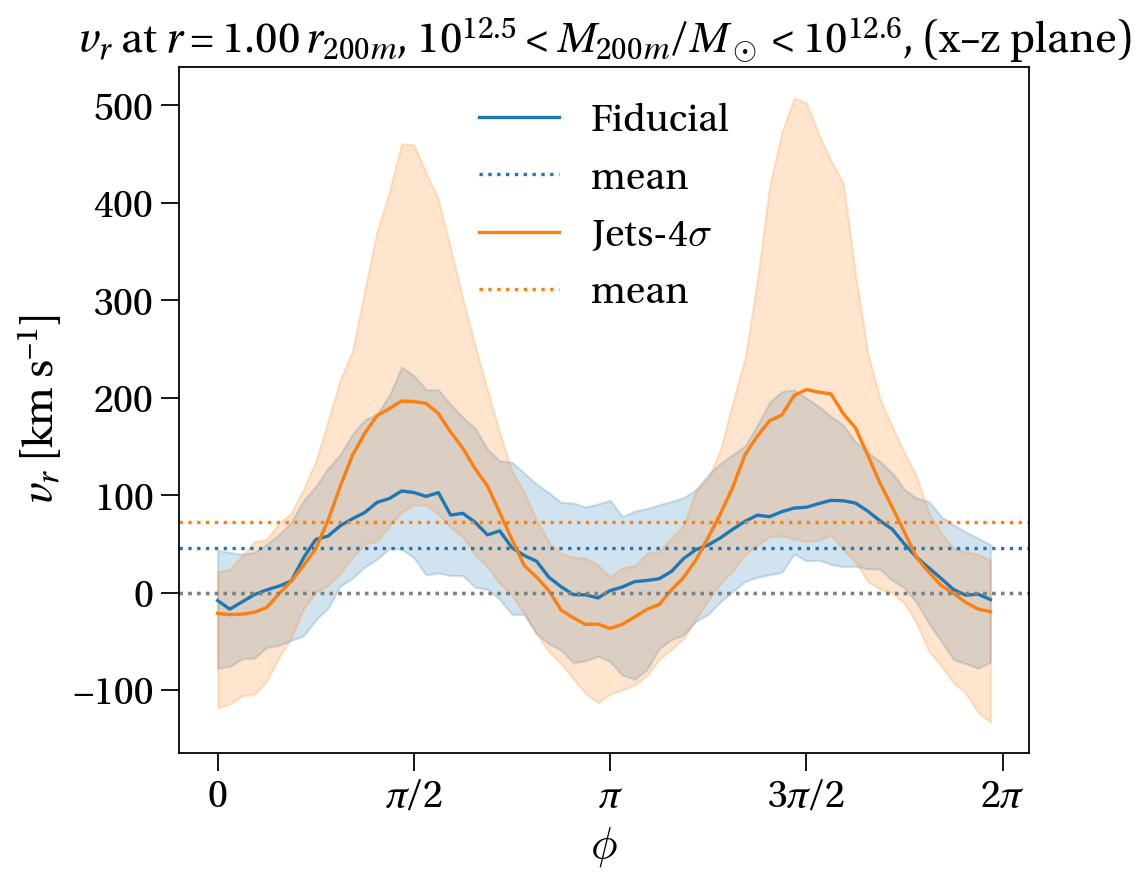

In [83]:
fa.make_stacked_vr_plot("L0200N0360_HYDRO_FIDUCIAL/%4.hdf5", M_min=12.5, M_max=12.6, axis='13', r_frac=1.0, with_mean_reference=True,
                        stack_mode=(16, 84))
fa.make_stacked_vr_plot("L0200N0360_HYDRO_JETS_STRONGER_AGN/%4.hdf5", M_min=12.5, M_max=12.6, axis='13', r_frac=1.0, with_mean_reference=True,
                        stack_mode=(16, 84))

fa.legend(['Fiducial', 'mean', None, 'Jets-4$\sigma$', 'mean'], loc='best')

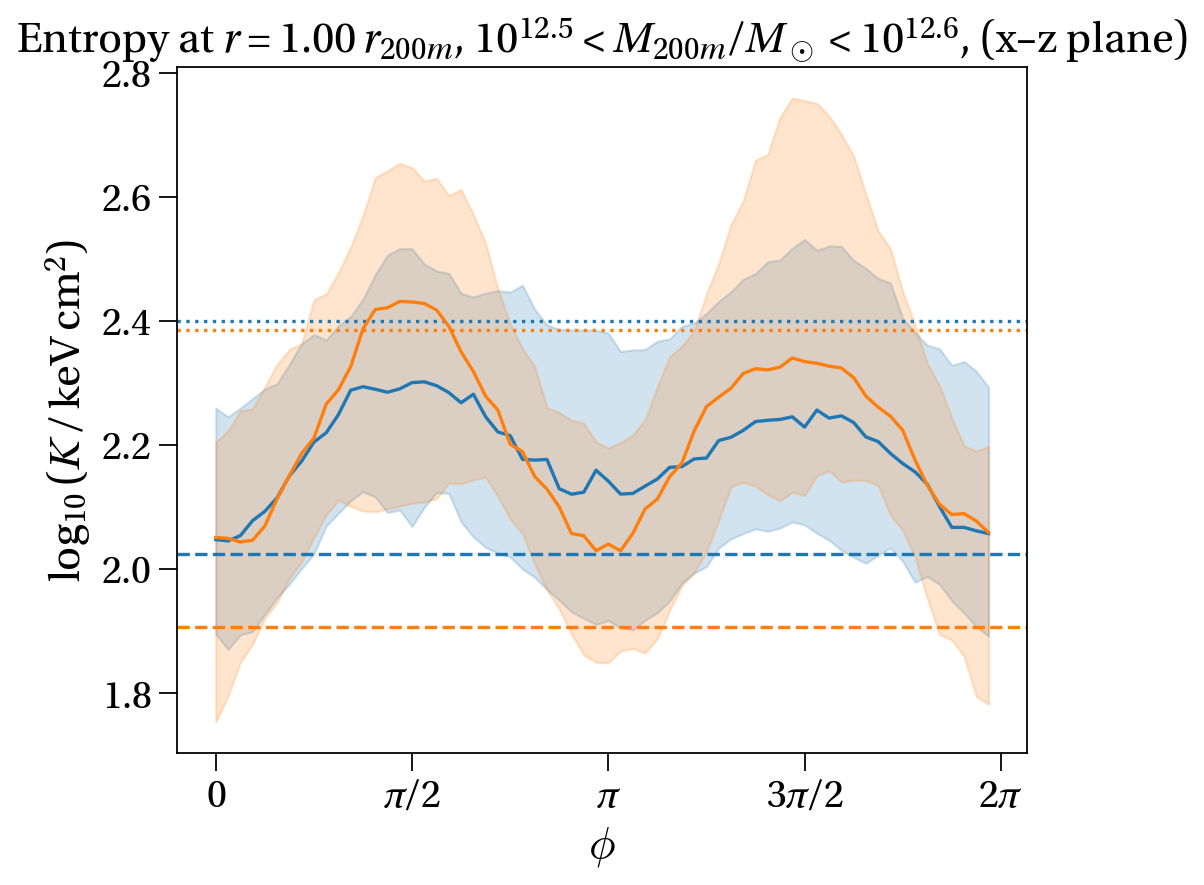

In [87]:
fa.make_stacked_entropy_angle_plot("L0200N0360_HYDRO_FIDUCIAL/%4.hdf5", M_min=12.5, M_max=12.6, axis='13', r_frac=1.0,
                                   stack_mode=(16, 84), show_reference_values=True)
fa.make_stacked_entropy_angle_plot("L0200N0360_HYDRO_JETS_STRONGER_AGN/%4.hdf5", M_min=12.5, M_max=12.6, axis='13', r_frac=1.0,
                                   stack_mode=(16, 84), show_reference_values=True)